In [16]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PARQUET_DIR = Path("/Users/gilyginosar/Dropbox (Personal)/Vocalizations_project/Data/parquet_cache")

FIGURES_DIR = Path("/Users/gilyginosar/Dropbox (Personal)/Vocalizations_project/Figures/alarm")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name):
    fig.savefig(FIGURES_DIR / f"{name}.pdf", bbox_inches="tight")



# Shared analysis settings — change here, every plotting cell picks them up.
DATES_TO_PLOT = ["2025_03", "2025_07", "2025_10", "2026_02"]
DAYS_PER_DATE = None   # int = keep first N days; None = use all days
N = 10              # minutes per bin
LIGHT_DEFAULT = (8, 20)
LIGHT_OVERRIDES = {"2026_02": (4, 16)}



In [17]:
# create alarm df for all dates

parts = []
for date_tag in DATES_TO_PLOT:
    df_d = pd.read_parquet(PARQUET_DIR / f"all_calls_{date_tag}.parquet")
    if DAYS_PER_DATE is not None:
        df_d = df_d[df_d["day_in_experiment"] <= DAYS_PER_DATE]
    df_d = df_d[df_d["event_type"] == "alarm"]
    parts.append(df_d)

alarm = pd.concat(parts, ignore_index=True)
print(f"{len(alarm):,} alarm calls across {len(DATES_TO_PLOT)} dates")
alarm.info()


23,560 alarm calls across 4 dates
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23560 entries, 0 to 23559
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   exp                        23560 non-null  int64         
 1   file_num                   23560 non-null  int64         
 2   event_type                 23560 non-null  object        
 3   start_time_file_sec        23560 non-null  float64       
 4   stop_time_file_sec         23560 non-null  float64       
 5   duration_sec               23560 non-null  float64       
 6   assigned_location          23560 non-null  object        
 7   channel                    23560 non-null  int64         
 8   meanprob_noise             23560 non-null  float64       
 9   meanprob_alarm             23560 non-null  float64       
 10  meanprob_high_freq         23560 non-null  float64       
 11  meanprob_newborn           23560 

In [18]:
ICI_BOUT_THRESHOLD_S = 5.0

alarm = alarm.sort_values(
    ["date_folder", "exp", "assigned_location", "start_time_real"]
).reset_index(drop=True)

prev_stop = alarm.groupby(
    ["date_folder", "exp", "assigned_location"]
)["stop_time_real"].shift(1)
gaps = alarm["start_time_real"] - prev_stop

is_new_bout = gaps.isna() | (gaps > pd.Timedelta(seconds=ICI_BOUT_THRESHOLD_S))
alarm["bout_id"]   = is_new_bout.cumsum()
alarm["bout_size"] = alarm.groupby("bout_id")["bout_id"].transform("size")
alarm["position"]  = alarm.groupby("bout_id").cumcount() + 1

print(f"{alarm['bout_id'].nunique():,} bouts total")
print(f"{(alarm['bout_size'] > 1).sum():,} alarm calls in multi-call bouts "
      f"({(alarm['bout_size'] > 1).mean()*100:.1f}%)")


6,034 bouts total
19,853 alarm calls in multi-call bouts (84.3%)


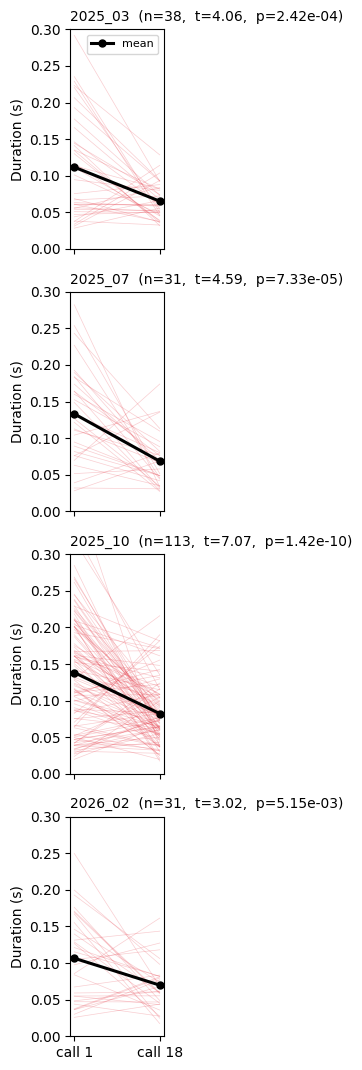

In [49]:
from scipy import stats

LAST_POS = 18
   # change this to compare call 1 vs call N

fig, axes = plt.subplots(
    len(DATES_TO_PLOT), 1,
    figsize=(2, 2.7 * len(DATES_TO_PLOT)),
    sharex=True,
    sharey=True,
)

for ax, date_tag in zip(axes, DATES_TO_PLOT):
    sub = alarm[
        (alarm["date_folder"] == date_tag)
        & (alarm["bout_size"] >= LAST_POS)
        & (alarm["assigned_location"] == "underground")
    ]
    if sub.empty:
        ax.text(0.5, 0.5, "no qualifying bouts",
                ha="center", va="center", transform=ax.transAxes)
        continue

    mat = sub.pivot(index="bout_id", columns="position", values="duration_sec")

    # Pull the two columns we care about, align on bout_id, drop any NaN pair.
    pair = pd.concat({"first": mat[1], "last": mat[LAST_POS]}, axis=1).dropna()

    # Paired t-test: each first-call vs its own bout's Nth-call.
    t_stat, p_val = stats.ttest_rel(pair["first"], pair["last"])

    # Slopegraph: one line per bout, from "first" to "last".
    ax.plot(
        [0, 1],
        np.vstack([pair["first"].values, pair["last"].values]),
        color="#E63946", alpha=0.25, linewidth=0.5,
    )

    # Mean overlay so the population shift pops out.
    ax.plot([0, 1], [pair["first"].mean(), pair["last"].mean()],
            color="black", linewidth=2.2, marker="o", markersize=5,
            label="mean", zorder=10)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["call 1", f"call {LAST_POS}"])
    ax.set_ylim([0,0.3])
    ax.set_ylabel("Duration (s)")
    ax.set_title(
        f"{date_tag}  (n={len(pair)},  t={t_stat:.2f},  p={p_val:.2e})",
        loc="left", fontsize=10,
    )

axes[0].legend(loc="upper right", fontsize=8)
fig.tight_layout()
save_fig(fig, f"alarm_first_vs_call{LAST_POS}_paired")
plt.show()

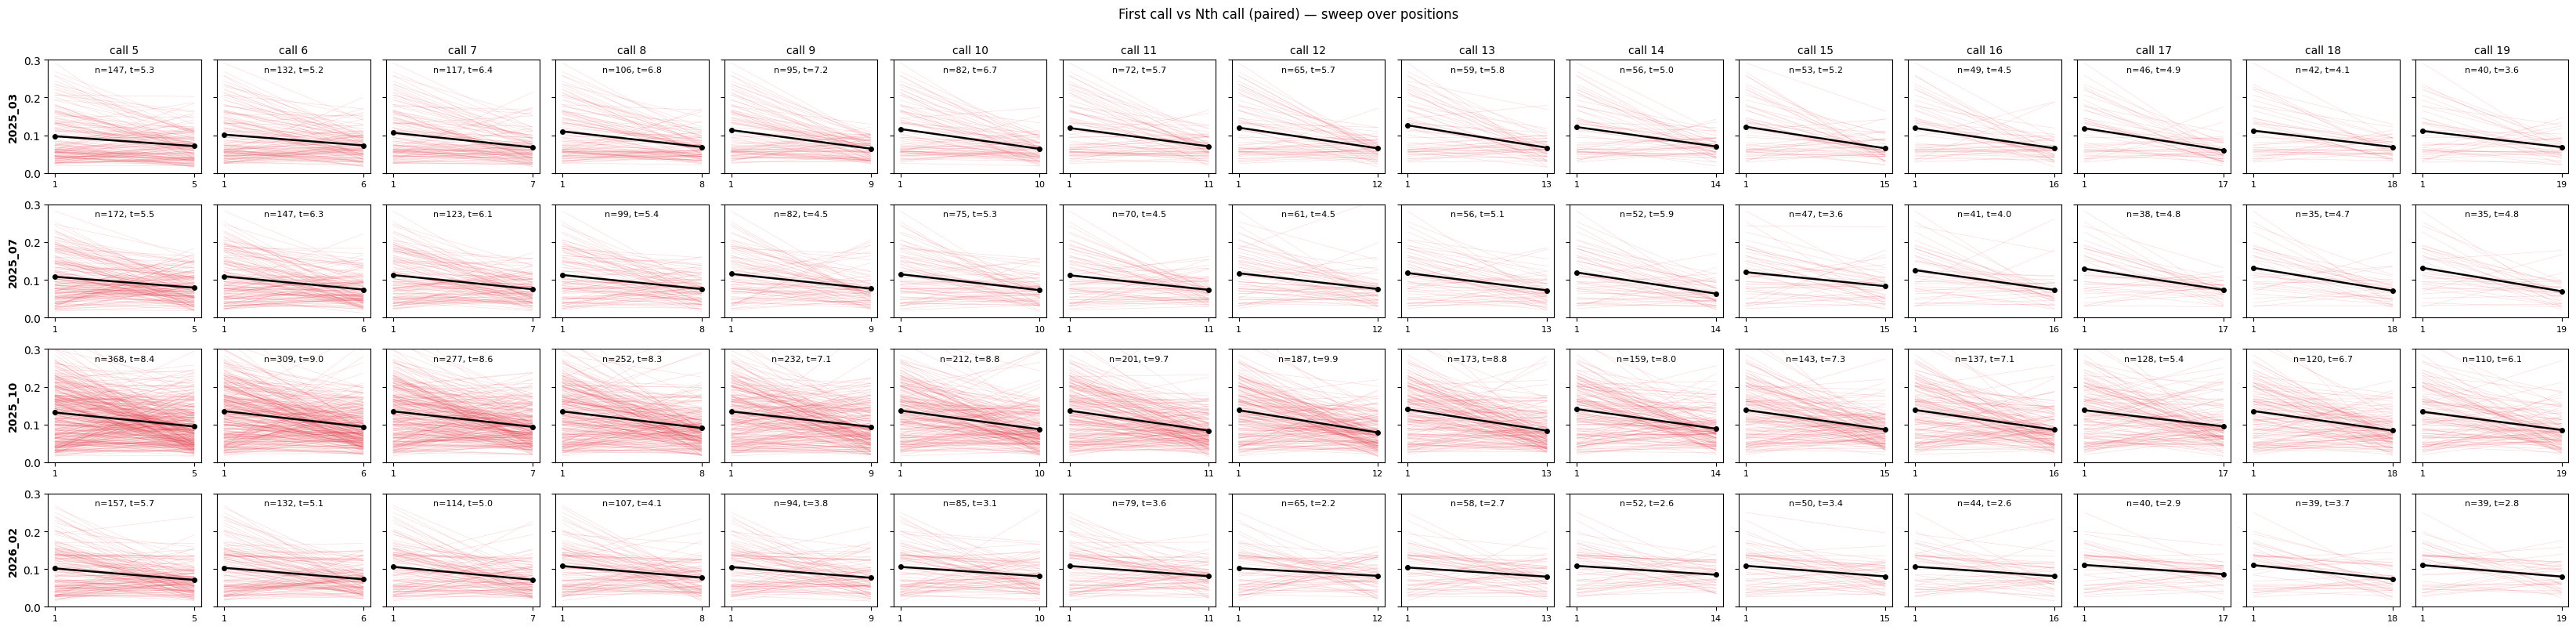

In [34]:
SWEEP_POSITIONS = list(range(5, 20))   # 5, 6, 7, 8, 9, 10

fig, axes = plt.subplots(
    len(DATES_TO_PLOT), len(SWEEP_POSITIONS),
    figsize=(2.2 * len(SWEEP_POSITIONS), 2.0 * len(DATES_TO_PLOT)),
    sharey=True,   # each date's row shares y-scale across positions
)

for r, date_tag in enumerate(DATES_TO_PLOT):
    for c, last_pos in enumerate(SWEEP_POSITIONS):
        ax = axes[r, c]

        sub = alarm[
            (alarm["date_folder"] == date_tag)
            & (alarm["bout_size"] >= last_pos)
        ]
        if sub.empty:
            ax.set_axis_off()
            continue

        mat = sub.pivot(index="bout_id", columns="position", values="duration_sec")
        pair = pd.concat({"first": mat[1], "last": mat[last_pos]}, axis=1).dropna()

        if len(pair) < 5:
            ax.text(0.5, 0.5, f"n={len(pair)}",
                    ha="center", va="center", transform=ax.transAxes, fontsize=8)
            ax.set_xticks([])
            continue

        t_stat, p_val = stats.ttest_rel(pair["first"], pair["last"])

        ax.plot([0, 1],
                np.vstack([pair["first"].values, pair["last"].values]),
                color="#E63946", alpha=0.2, linewidth=0.4)
        ax.plot([0, 1],
                [pair["first"].mean(), pair["last"].mean()],
                color="black", linewidth=1.8, marker="o", markersize=4)

        ax.set_xticks([0, 1])
        ax.set_xticklabels(["1", str(last_pos)], fontsize=8)

        if r == 0:
            ax.set_title(f"call {last_pos}", fontsize=10)
        ax.text(0.5, 0.95,
                f"n={len(pair)}, t={t_stat:.1f}",
                transform=ax.transAxes, ha="center", va="top", fontsize=8)

        if c == 0:
            ax.set_ylabel(f"{date_tag}", fontweight="bold")
        ax.set_ylim([0, 0.3])
fig.suptitle("First call vs Nth call (paired) — sweep over positions",
             y=1.0, fontsize=12)
fig.tight_layout()
save_fig(fig, "alarm_first_vs_nth_sweep")
plt.show()


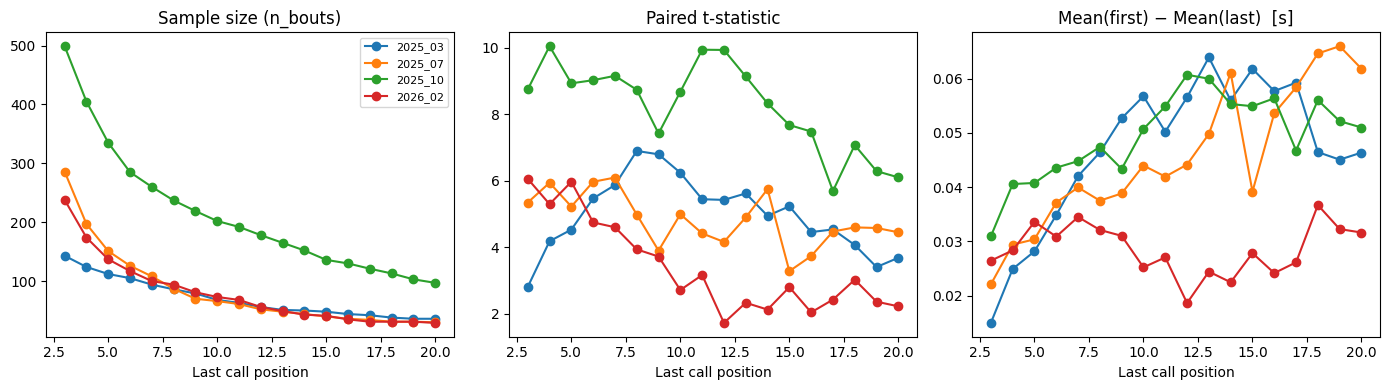

In [50]:
SWEEP_POSITIONS = list(range(3, 21))  # extend further if you want

results = []
for date_tag in DATES_TO_PLOT:
    for last_pos in SWEEP_POSITIONS:
        sub = alarm[(alarm["date_folder"] == date_tag) & (alarm["bout_size"] >= last_pos)& (alarm["assigned_location"] == "underground")]
        if sub.empty:
            continue
        mat = sub.pivot(index="bout_id", columns="position", values="duration_sec")
        pair = pd.concat({"first": mat[1], "last": mat[last_pos]}, axis=1).dropna()
        if len(pair) < 5:
            continue
        t_stat, p_val = stats.ttest_rel(pair["first"], pair["last"])
        results.append({"date_folder": date_tag, "last_pos": last_pos,
                        "n": len(pair), "t": t_stat,
                        "diff_mean": pair["first"].mean() - pair["last"].mean()})

summary = pd.DataFrame(results)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True)
for date_tag, g in summary.groupby("date_folder"):
    axes[0].plot(g["last_pos"], g["n"], marker="o", label=date_tag)
    axes[1].plot(g["last_pos"], g["t"], marker="o", label=date_tag)
    axes[2].plot(g["last_pos"], g["diff_mean"], marker="o", label=date_tag)
axes[0].set_title("Sample size (n_bouts)")
axes[1].set_title("Paired t-statistic")
axes[2].set_title("Mean(first) − Mean(last)  [s]")
for ax in axes:
    ax.set_xlabel("Last call position")
axes[0].legend(fontsize=8)
fig.tight_layout()
plt.show()


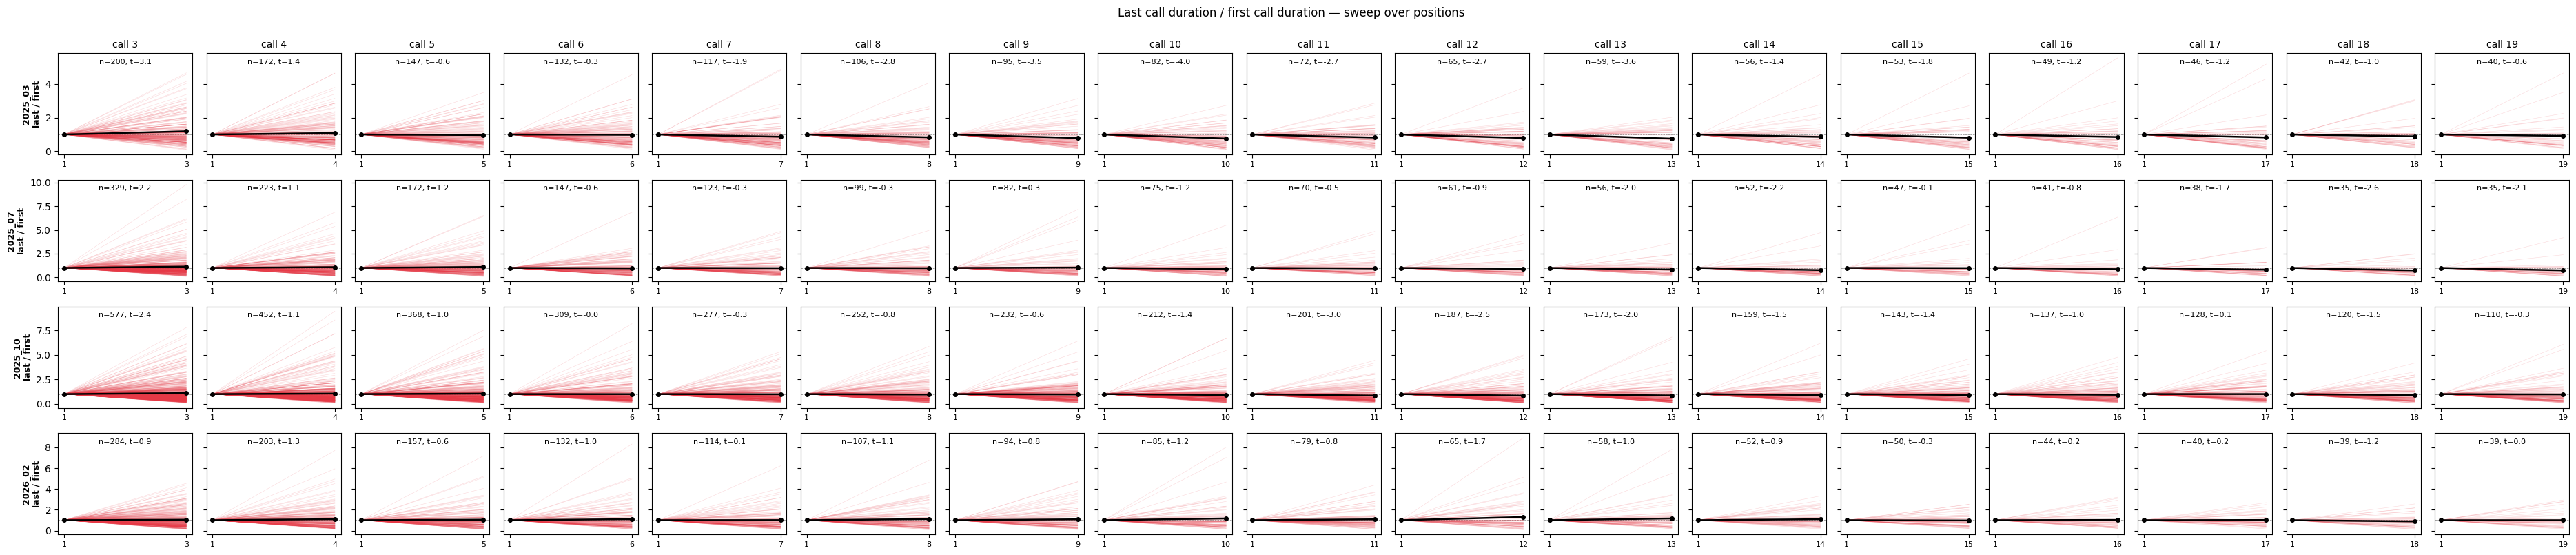

In [41]:
SWEEP_POSITIONS = list(range(3, 20))

fig, axes = plt.subplots(
    len(DATES_TO_PLOT), len(SWEEP_POSITIONS),
    figsize=(2.2 * len(SWEEP_POSITIONS), 2.0 * len(DATES_TO_PLOT)),
    sharey="row",
)

for r, date_tag in enumerate(DATES_TO_PLOT):
    for c, last_pos in enumerate(SWEEP_POSITIONS):
        ax = axes[r, c]

        sub = alarm[
            (alarm["date_folder"] == date_tag)
            & (alarm["bout_size"] >= last_pos)
        ]
        if sub.empty:
            ax.set_axis_off()
            continue

        mat = sub.pivot(index="bout_id", columns="position", values="duration_sec")
        pair = pd.concat({"first": mat[1], "last": mat[last_pos]}, axis=1).dropna()
        pair = pair[pair["first"] > 0]   # avoid divide-by-zero

        if len(pair) < 5:
            ax.text(0.5, 0.5, f"n={len(pair)}", ha="center", va="center",
                    transform=ax.transAxes, fontsize=8)
            ax.set_xticks([])
            continue

        # Normalize: each bout's last / first.
        ratio = pair["last"] / pair["first"]

        # One-sample t-test: is mean(ratio) significantly different from 1?
        t_stat, p_val = stats.ttest_1samp(ratio, 1.0)

        ax.plot([0, 1],
                np.vstack([np.ones(len(ratio)), ratio.values]),
                color="#E63946", alpha=0.2, linewidth=0.4)
        ax.plot([0, 1], [1.0, ratio.mean()],
                color="black", linewidth=1.8, marker="o", markersize=4)
        ax.axhline(1.0, color="grey", linestyle="--", linewidth=0.5, zorder=0)

        ax.set_xticks([0, 1])
        ax.set_xticklabels(["1", str(last_pos)], fontsize=8)
        if r == 0:
            ax.set_title(f"call {last_pos}", fontsize=10)
        ax.text(0.5, 0.95, f"n={len(ratio)}, t={t_stat:.1f}",
                transform=ax.transAxes, ha="center", va="top", fontsize=8)
        if c == 0:
            ax.set_ylabel(f"{date_tag}\nlast / first", fontweight="bold", fontsize=9)

fig.suptitle("Last call duration / first call duration — sweep over positions",
             y=1.0, fontsize=12)
fig.tight_layout()
save_fig(fig, "alarm_first_vs_nth_sweep_ratio")
plt.show()


In [52]:
LAST_POS = 7
TOP_N = 100

sub = alarm[alarm["bout_size"] >= LAST_POS & (alarm["assigned_location"] == "underground")]
mat = sub.pivot(index="bout_id", columns="position", values="duration_sec")

# Per-bout first/last/diff.
pair = pd.concat({"first": mat[1], "last": mat[LAST_POS]}, axis=1).dropna()
pair["diff"] = pair["first"] - pair["last"]

# First-call metadata per bout (position == 1 row of each bout).
first_calls_info = (
    sub[sub["position"] == 1]
    .set_index("bout_id")
    [["date_folder", "exp", "file_num", "start_time_file_sec", "assigned_location"]]
)

# Join on bout_id index, sort by drop magnitude.
sorted_bouts = pair.join(first_calls_info).sort_values("diff", ascending=False)

print(f"Top {TOP_N} bouts by (first − call {LAST_POS}) duration drop:")
print(sorted_bouts.head(TOP_N).to_string())


Top 100 bouts by (first − call 7) duration drop:
            first      last      diff date_folder  exp  file_num  start_time_file_sec assigned_location
bout_id                                                                                                
3879     0.389248  0.094336  0.294912     2025_10  341         1            14.165760       underground
3241     0.299512  0.035840  0.263672     2025_10  337       456            90.188928       underground
3693     0.331000  0.096888  0.234112     2025_10  340       151           326.400256       underground
2625     0.269944  0.044288  0.225656     2025_10  333       177           174.539136       underground
3764     0.258168  0.042880  0.215288     2025_10  340       197           220.098432       underground
3748     0.229120  0.018944  0.210176     2025_10  340       192           132.811776       underground
1321     0.253824  0.043896  0.209928     2025_07  276        11            34.605952       underground
1341     0.2822

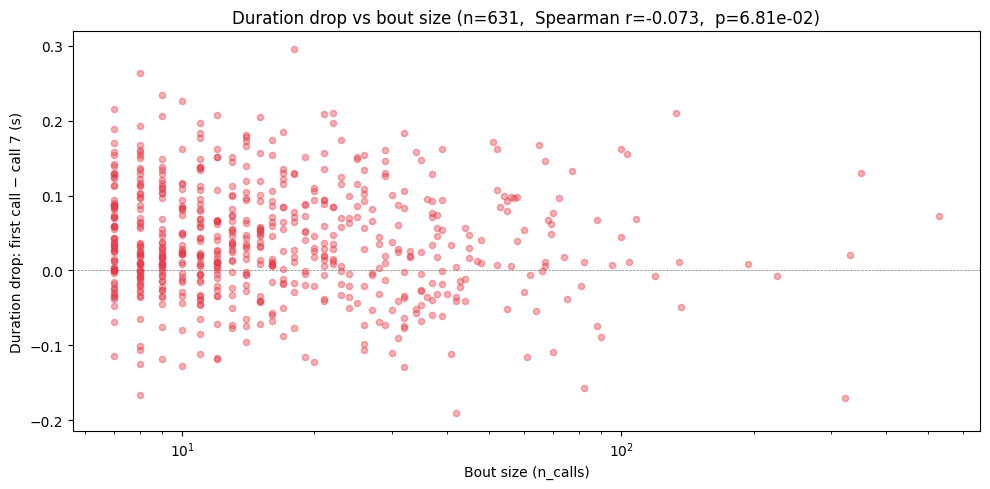

In [53]:
from scipy.stats import spearmanr

LAST_POS = 7

sub = alarm[alarm["bout_size"] >= LAST_POS& (alarm["assigned_location"] == "underground")]
mat = sub.pivot(index="bout_id", columns="position", values="duration_sec")
pair = pd.concat({"first": mat[1], "last": mat[LAST_POS]}, axis=1).dropna()
pair["diff"] = pair["first"] - pair["last"]
pair["bout_size"] = sub.groupby("bout_id")["bout_size"].first()

# Spearman correlation — robust to outliers, doesn't assume linearity.
rho, p_val = spearmanr(pair["bout_size"], pair["diff"])

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(pair["bout_size"], pair["diff"],
           alpha=0.4, s=20, color="#E63946")
ax.axhline(0, color="grey", linestyle="--", linewidth=0.5, zorder=0)
ax.set_xscale("log")
ax.set_xlabel("Bout size (n_calls)")
ax.set_ylabel(f"Duration drop: first call − call {LAST_POS} (s)")
ax.set_title(
    f"Duration drop vs bout size (n={len(pair)},  "
    f"Spearman r={rho:.3f},  p={p_val:.2e})"
)
fig.tight_layout()
save_fig(fig, "alarm_diff_vs_bout_size")
plt.show()


In [54]:
LAST_POS = 7

sub = alarm[alarm["bout_size"] >= LAST_POS& (alarm["assigned_location"] == "underground")]

mat = sub.pivot(index="bout_id", columns="position", values="duration_sec")
pair = pd.concat({"first": mat[1], "last": mat[LAST_POS]}, axis=1).dropna()
pair["diff"] = pair["first"] - pair["last"]

# Split into quartiles.
q25, q75 = pair["diff"].quantile([0.25, 0.75])
pair["drop_class"] = pd.cut(
    pair["diff"],
    bins=[-np.inf, q25, q75, np.inf],
    labels=["small", "middle", "big"],
)

# Map class back to every alarm call in those bouts.
alarm_with_class = alarm.copy()
alarm_with_class["drop_class"] = alarm_with_class["bout_id"].map(pair["drop_class"])
classed = alarm_with_class.dropna(subset=["drop_class"])

# One row per bout — useful for any per-bout feature comparison.
per_bout = classed.groupby("bout_id").first()


In [55]:
print("Per-bout features by drop class:")
print(per_bout.groupby("drop_class").agg(
    n_bouts=("date_folder", "size"),
    median_bout_size=("bout_size", "median"),
    mean_bout_size=("bout_size", "mean"),
    median_meanprob_alarm=("meanprob_alarm", "median"),
))

print("\nLocation distribution (column-normalized):")
print(pd.crosstab(per_bout["assigned_location"], per_bout["drop_class"], normalize="columns"))

print("\nDate distribution (column-normalized):")
print(pd.crosstab(per_bout["date_folder"], per_bout["drop_class"], normalize="columns"))


Per-bout features by drop class:
            n_bouts  median_bout_size  mean_bout_size  median_meanprob_alarm
drop_class                                                                  
small           158              15.0       24.563291               0.872246
middle          315              13.0       23.942857               0.889621
big             158              14.0       22.518987               0.909705

Location distribution (column-normalized):
drop_class            small    middle       big
assigned_location                              
arena_1            0.107595  0.082540  0.025316
arena_2            0.018987  0.050794  0.018987
underground        0.873418  0.866667  0.955696

Date distribution (column-normalized):
drop_class      small    middle       big
date_folder                              
2025_03      0.139241  0.215873  0.170886
2025_07      0.196203  0.206349  0.170886
2025_10      0.468354  0.400000  0.487342
2026_02      0.196203  0.177778  0.170886


/var/folders/bc/jhnbh5zj37x8z2_yzyp_3nhh0000gr/T/ipykernel_21288/590183697.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(per_bout.groupby("drop_class").agg(


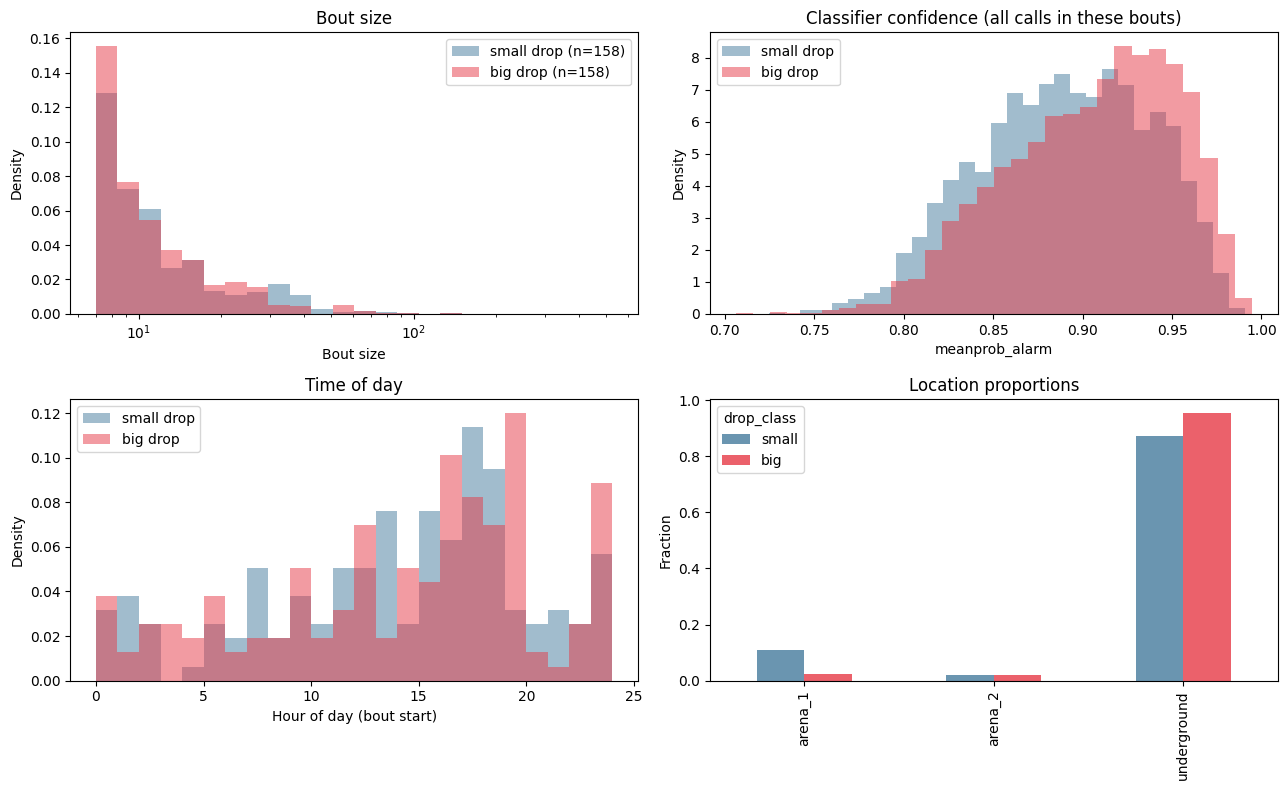

In [56]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# 1. Bout size: log-scale histogram.
ax = axes[0, 0]
edges = np.geomspace(LAST_POS, per_bout["bout_size"].max(), 25)
for label, color in [("small", "#457B9D"), ("big", "#E63946")]:
    g = per_bout[per_bout["drop_class"] == label]
    ax.hist(g["bout_size"], bins=edges, alpha=0.5, color=color,
            label=f"{label} drop (n={len(g)})", density=True)
ax.set_xscale("log")
ax.set_xlabel("Bout size")
ax.set_ylabel("Density")
ax.set_title("Bout size")
ax.legend()

# 2. Classifier confidence — across all calls in these bouts (not just the first).
ax = axes[0, 1]
for label, color in [("small", "#457B9D"), ("big", "#E63946")]:
    g = classed[classed["drop_class"] == label]
    ax.hist(g["meanprob_alarm"], bins=30, alpha=0.5, color=color,
            label=f"{label} drop", density=True)
ax.set_xlabel("meanprob_alarm")
ax.set_ylabel("Density")
ax.set_title("Classifier confidence (all calls in these bouts)")
ax.legend()

# 3. Hour of day (bout start).
ax = axes[1, 0]
for label, color in [("small", "#457B9D"), ("big", "#E63946")]:
    g = per_bout[per_bout["drop_class"] == label]
    ax.hist(g["start_time_real"].dt.hour, bins=24, range=(0, 24),
            alpha=0.5, color=color, label=f"{label} drop", density=True)
ax.set_xlabel("Hour of day (bout start)")
ax.set_ylabel("Density")
ax.set_title("Time of day")
ax.legend()

# 4. Location proportions.
ax = axes[1, 1]
prop = pd.crosstab(per_bout["assigned_location"], per_bout["drop_class"], normalize="columns")
prop[["small", "big"]].plot.bar(
    ax=ax, color=["#457B9D", "#E63946"], alpha=0.8,
)
ax.set_ylabel("Fraction")
ax.set_title("Location proportions")
ax.set_xlabel("")

fig.tight_layout()
save_fig(fig, "alarm_high_vs_low_drop_features")
plt.show()
